# Каналы `datasets.transforms`

Демонстрация экстракторов из `datasets/transforms/extract.py` на одном сэмпле `TermoDataset`.
Без аугментаций и без DataLoader (нет шаффла): берём `ds[INDEX]`.

Цепочка — те же классы, что на train/infer: `SelectFrames` → `Stack` → `PercentileNorm`.
`TSRDeriv(order=1|2)` — карты \(p'(u)\) и \(p''(u)\) полинома TSR (Seq 5 / Seq 6), в моменты \(n/8\) и \(n/2\) остывания.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "datasets" / "datasets.py").is_file())
sys.path.insert(0, str(ROOT / "datasets"))

from datasets import TermoDataset
from transforms import (
    Compose, Stack, SelectFrames,
    MaxMin, MaxFirst, Std, PCA1, TSR, TSRDeriv, PercentileNorm,
)

INCLUDE = None
INDEX = 7

extractors = [MaxMin(), MaxFirst(), Std(), PCA1(),
              TSRDeriv(order=1, at=(0.1, 0.25)), TSRDeriv(order=2, at=(0.05, 0.15))]
CAPTION = {
    "MaxMin": "MaxMin  —  max(t) − min(t)",
    "MaxFirst": "MaxFirst  —  max(t) − t₀",
    "Std": "Std  —  σ(t)",
    "PCA1": "PCA1  —  1-я временная мода",
}
titles = []
for e in extractors:
    name = type(e).__name__
    n = e.out_channels()
    if name == "TSR":
        titles.extend(f"{name} c{i}  —  полином {e.deg}°" for i in range(n))
    elif name == "TSRDeriv":
        kind = "p'" if e.order == 1 else "p''"
        titles.extend(f"{name} {kind}  —  t=n×{f:g}" for f in e.at)
    elif n == 1:
        titles.append(CAPTION[name])
    else:
        titles.extend(f"{name}[{i}]" for i in range(n))

tf = Compose([SelectFrames(), Stack(extractors), PercentileNorm()])

ds = TermoDataset(
    root_dir=str(ROOT / "datasets" / "datasets_list"),
    include=INCLUDE,
    transform=None,
)

video, mask = ds[INDEX]
channels, mask = tf(video.numpy(), mask.numpy())

stem = Path(ds.items[INDEX][0]).stem
print(stem, "video", tuple(video.shape), "channels", channels.shape)
print("кадры:", titles)

R_012 video (1810, 256, 256) channels (8, 256, 256)
кадры: ['MaxMin  —  max(t) − min(t)', 'MaxFirst  —  max(t) − t₀', 'Std  —  σ(t)', 'PCA1  —  1-я временная мода', "TSRDeriv p'  —  t=n×0.1", "TSRDeriv p'  —  t=n×0.25", "TSRDeriv p''  —  t=n×0.05", "TSRDeriv p''  —  t=n×0.15"]


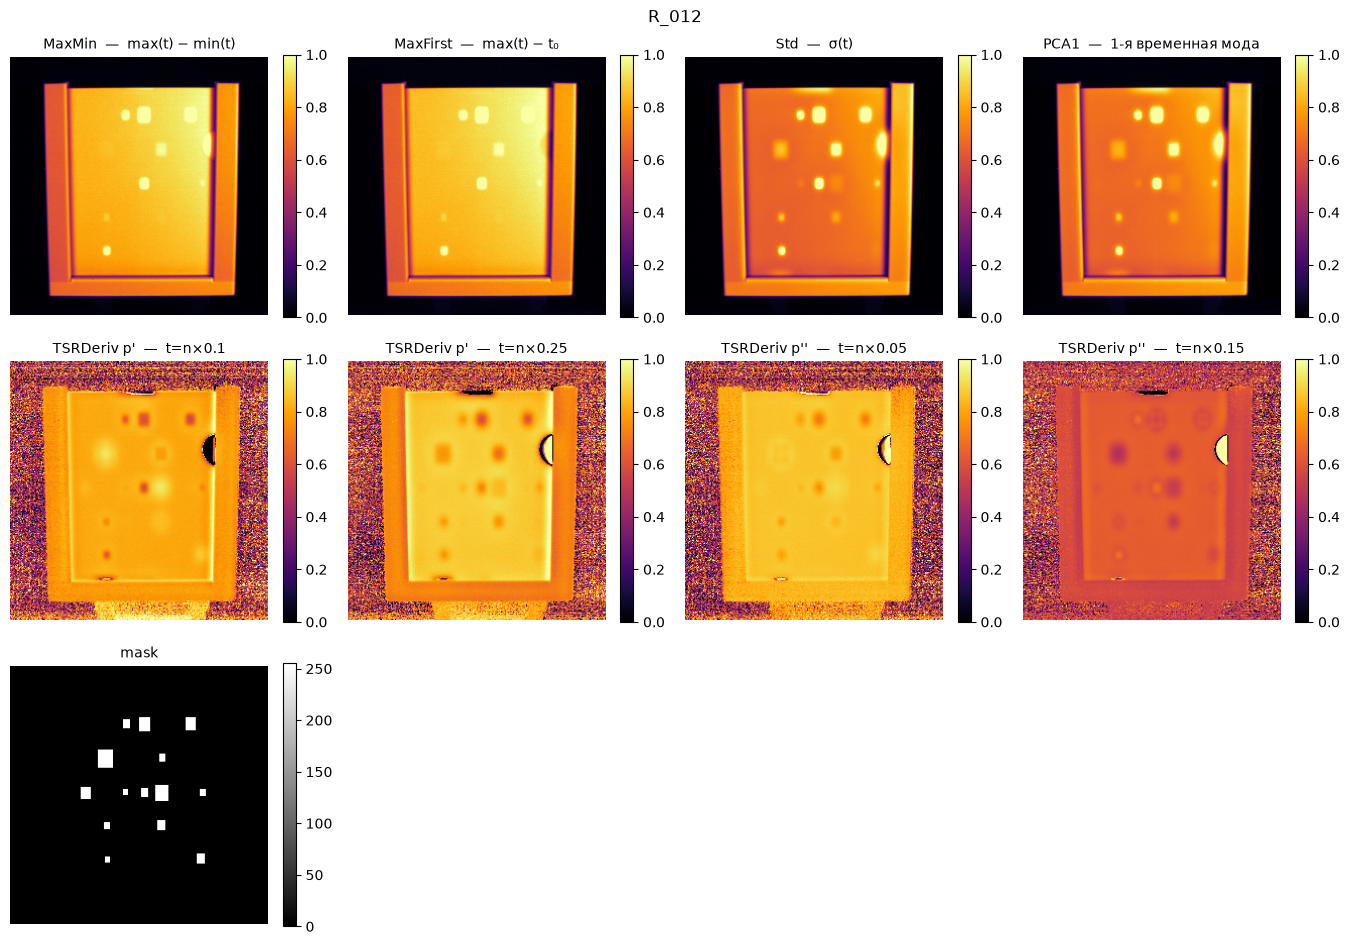

In [18]:
maps = list(zip(titles, channels))
maps.append(("mask", mask))

cols = 4
rows = (len(maps) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.4 * cols, 3.2 * rows))
for ax, (title, img) in zip(axes.ravel(), maps):
    if title == "mask":
        im = ax.imshow(img, cmap="gray")
    else:
        im = ax.imshow(img, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
for ax in axes.ravel()[len(maps):]:
    ax.axis("off")
fig.suptitle(stem)
fig.tight_layout()
plt.show()

## AppendDerivatives vs TSRDeriv

`AppendDerivatives` — не Seq 5/6 из статьи. После `TSR()` ось 0 уже **коэффициенты** \(c_0\ldots c_5\), не время. `np.diff` даёт \(c_{i+1}-c_i\) (режим `p5+d1` / `p5+d1+d2`).

`TSRDeriv` выше — наклон \(p'(u)\) / кривизна \(p''(u)\) в момент остывания. Ниже те же 6 коэфф., но через `AppendDerivatives`.

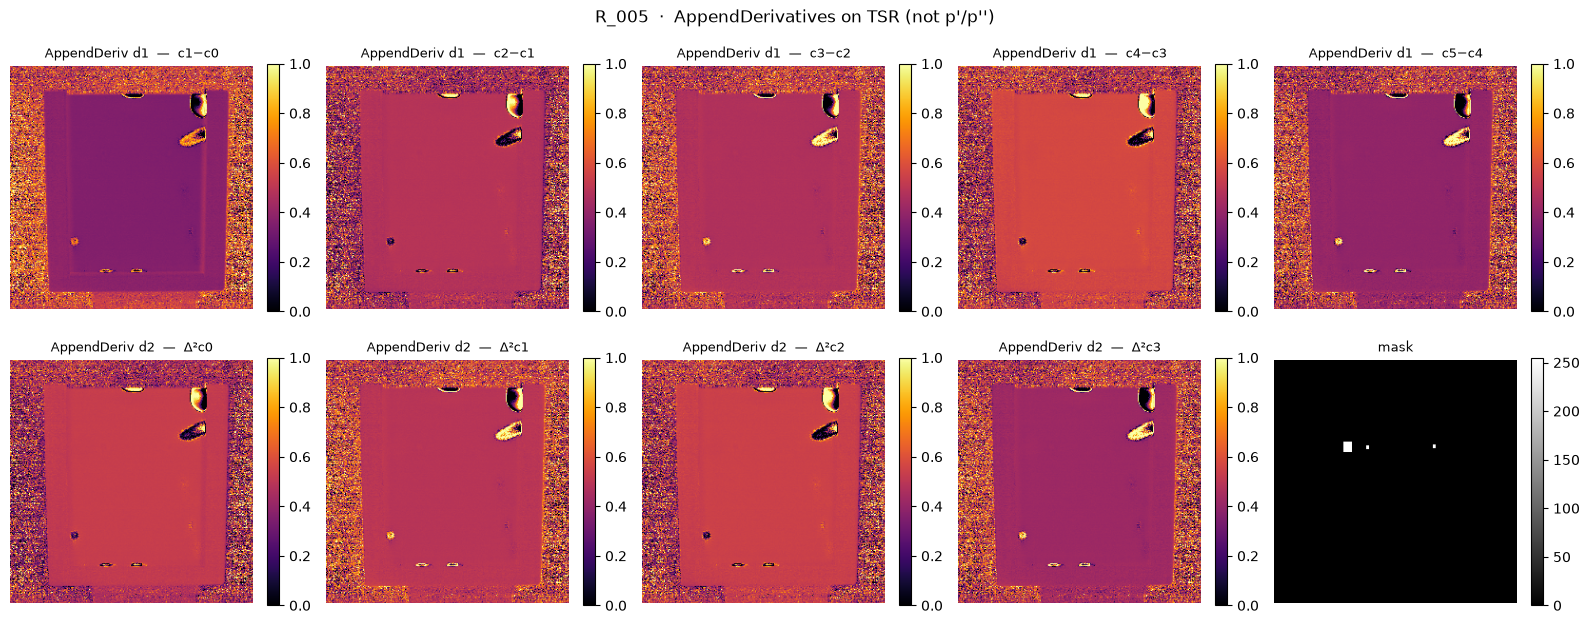

p5d1 (11, 256, 256) p5d2 (15, 256, 256)


In [10]:
from transforms import AppendDerivatives

def as_np(x):
    return x.numpy() if hasattr(x, "numpy") else x

v, m = as_np(video), as_np(mask)
tsr_c, _ = Compose([SelectFrames(), Stack([TSR()])])(v, m)
p5d1, _ = Compose([AppendDerivatives(1), PercentileNorm()])(tsr_c)
p5d2, _ = Compose([AppendDerivatives(2), PercentileNorm()])(tsr_c)

maps = (
    [(f"AppendDeriv d1  —  c{i + 1}−c{i}", p5d1[6 + i]) for i in range(5)]
    + [(f"AppendDeriv d2  —  Δ²c{i}", p5d2[11 + i]) for i in range(4)]
    + [("mask", mask)]
)

cols = 5
rows = (len(maps) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.2 * rows))
for ax, (title, img) in zip(axes.ravel(), maps):
    if title == "mask":
        im = ax.imshow(img, cmap="gray")
    else:
        im = ax.imshow(img, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
for ax in axes.ravel()[len(maps):]:
    ax.axis("off")
fig.suptitle(f"{stem}  ·  AppendDerivatives on TSR (not p'/p'')")
fig.tight_layout()
plt.show()
print("p5d1", p5d1.shape, "p5d2", p5d2.shape)